In [1]:
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from fermion import *
from entropy import RDM_entropy

exact_model = Fermion_Model(tunneling=1.0, coulomb=4.0)
analog_model = Analog_Fermion(exact_model)

initial_state = Statevector.from_label('0000111111110000').data  # Example initial state
time=np.linspace(0,10,101)
exact_state=initial_state
analog_state=initial_state
time_step=0.1
error=[]
entropy=[]
for _ in tqdm(time):
    analog_state = analog_model.evolve_state(exact_state, time_step, analog_model.H)
    exact_state = exact_model.evolve_state(exact_state, time_step, exact_model.H)
    error.append(np.linalg.norm(exact_state - analog_state))
    entropy.append(RDM_entropy(analog_state, 4,16)[-1])

100%|██████████| 101/101 [01:10<00:00,  1.43it/s]


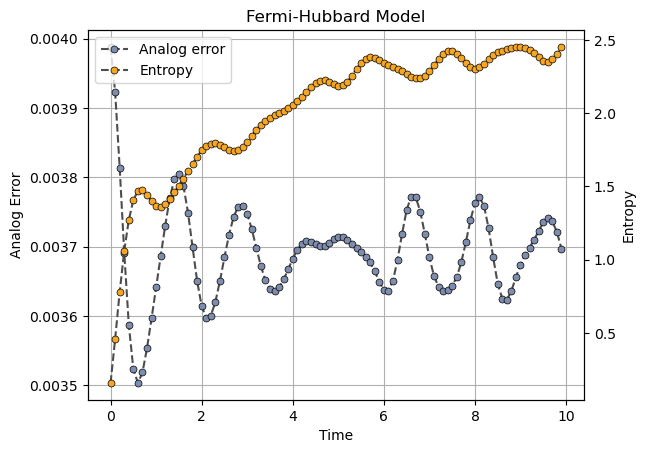

In [2]:
p11=plt.plot(time[:-1], error[:-1],color='0.3', marker='o', markersize=5, mfc="#7E8CAD", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Analog error')

plt.grid()
plt.xlabel('Time')
plt.ylabel('Analog Error')
# plt.ylim( top=0.3)
ax1=plt.gca()
ax2 = ax1.twinx()
p2=ax2.plot(time[:-1], entropy[:-1],color='0.3', marker='o', markersize=5, mfc="#F5A623", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Entropy')
ax2.set_ylabel('Entropy')
lns=p11+p2
labs=[l.get_label() for l in lns]
plt.legend(lns, labs, loc=0)

plt.title('Fermi-Hubbard Model')
plt.show()
